Generating internal data network connections...
Success! Image saved as: castlefield_neon_network_transparent.png


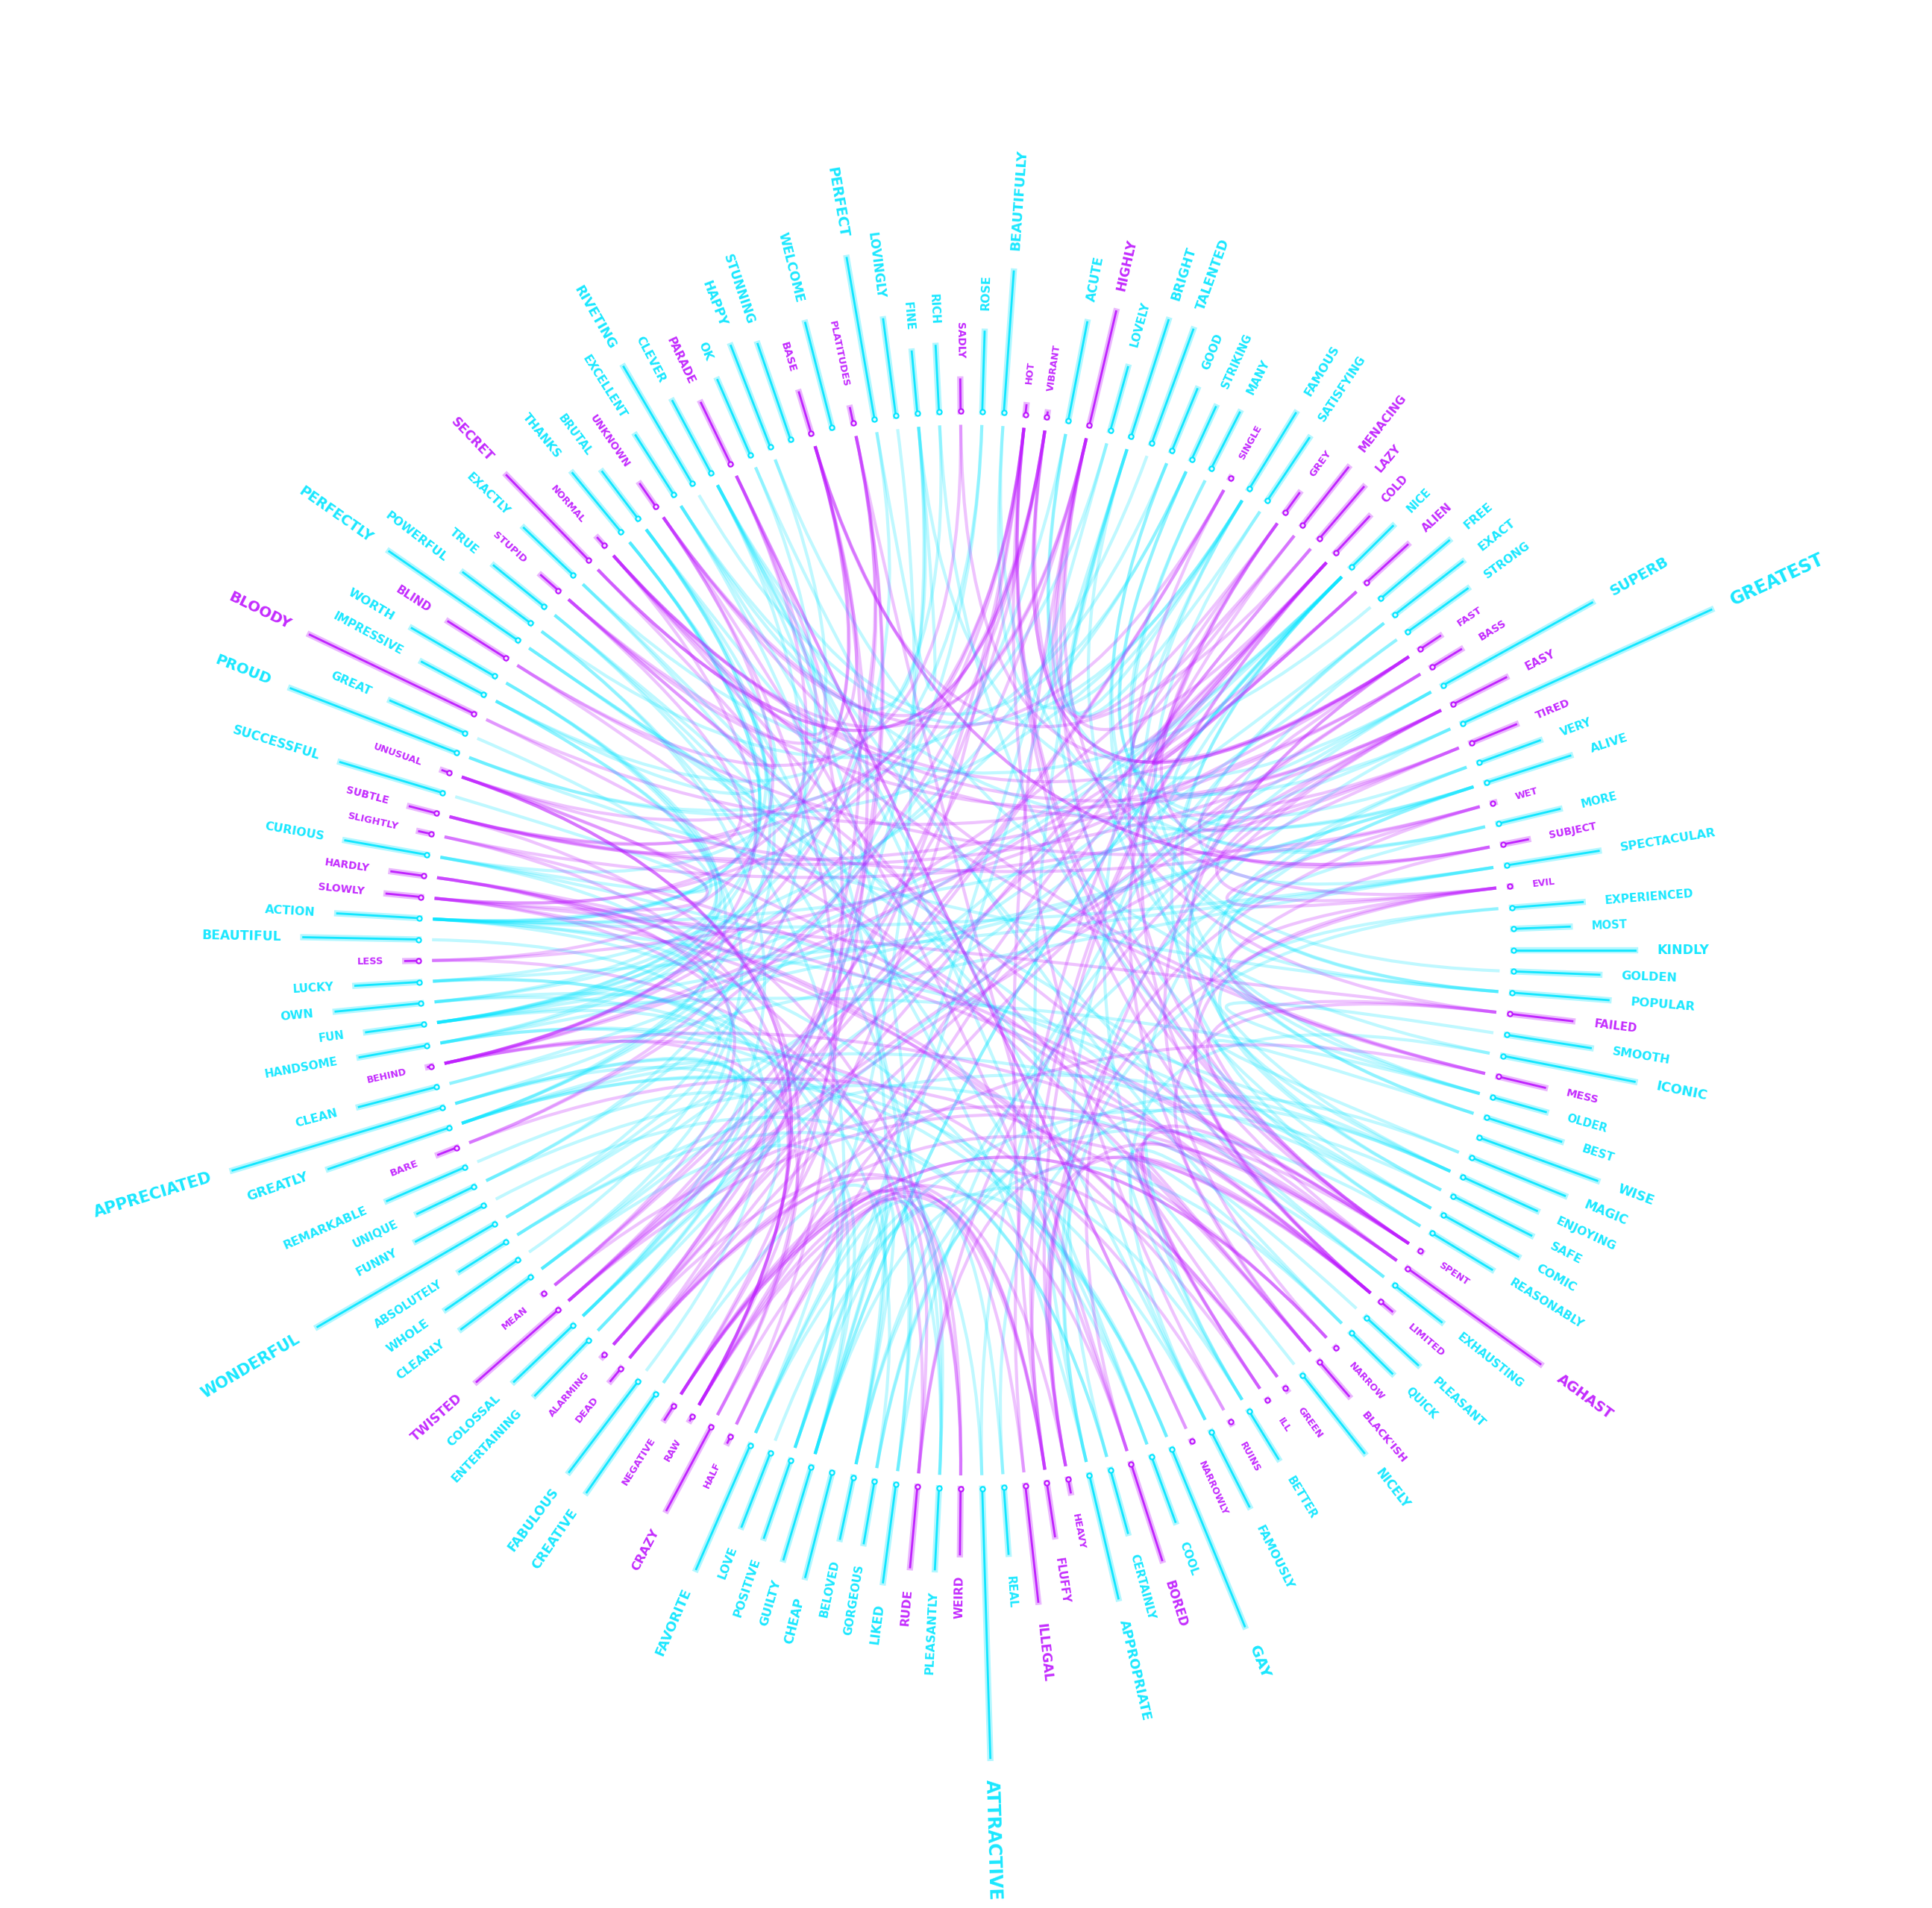

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import matplotlib.patches as mpatches

# 1. Read the data
df = pd.read_csv('castlefield_sentiment_keywords.csv').dropna()

# 2. Process keywords: since a row might contain multiple words, split and flatten them
words_data = []
for _, row in df.iterrows():
    pol = row['polarity']
    kws = str(row['keywords']).split(',')
    for kw in kws:
        kw = kw.strip().upper()
        if kw:
            words_data.append({'word': kw, 'polarity': pol})

word_df = pd.DataFrame(words_data)

# 3. Aggregate identical words, calculate mean polarity and appearance count
word_df = word_df.groupby('word').agg(
    polarity=('polarity', 'mean'),
    count=('polarity', 'count')
).reset_index()

word_df['abs_pol'] = word_df['polarity'].abs()

# 4. Extract the top 200 most representative words (100 strongest negative, 100 strongest positive)
if len(word_df) > 200:
    neg = word_df[word_df['polarity'] < 0].sort_values('polarity').head(100)
    pos = word_df[word_df['polarity'] > 0].sort_values('polarity', ascending=False).head(100)
    word_df = pd.concat([neg, pos]).reset_index(drop=True)

# 5. Randomly shuffle the order to intertwine the blue and purple nodes (breaks rigidity)
np.random.seed(42) # Set seed for reproducibility; change this number for a different random layout
word_df = word_df.sample(frac=1).reset_index(drop=True)

# 6. Canvas setup
N = len(word_df)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False)

# Create figure without a solid background color
fig, ax = plt.subplots(figsize=(26, 26))

# Make the axes background completely transparent
ax.patch.set_alpha(0.0)

# Inner circle radius
R_inner = 20

# Neon color scheme
color_pos = '#00e5ff' # Neon Cyan
color_neg = '#bc13fe' # Neon Purple

# Lists to store the node coordinates for internal chord connections
pos_nodes = []
neg_nodes = []

# 7. Draw the outer keywords and glowing bars
for i, row in word_df.iterrows():
    angle = angles[i]
    word = row['word']
    pol = row['polarity']
    abs_pol = row['abs_pol']

    # Determine color based on polarity
    color = color_pos if pol > 0 else color_neg

    # Record node coordinates
    if pol > 0:
        pos_nodes.append((angle, R_inner - 0.5))
    else:
        neg_nodes.append((angle, R_inner - 0.5))

    # Bar length maps to the absolute intensity of the sentiment
    line_len = abs_pol * 10

    # Start and end points of the bars
    x_start = R_inner * np.cos(angle)
    y_start = R_inner * np.sin(angle)
    x_end = (R_inner + line_len) * np.cos(angle)
    y_end = (R_inner + line_len) * np.sin(angle)

    # Draw glowing effect bars (overlaying a thick transparent line and a thin solid line)
    ax.plot([x_start, x_end], [y_start, y_end], color=color, alpha=0.3, lw=6) # Glow layer
    ax.plot([x_start, x_end], [y_start, y_end], color=color, alpha=0.9, lw=2) # Core layer

    # Draw inner glowing nodes
    ax.plot(x_start, y_start, marker='o', color=color, markersize=5, alpha=1.0)
    ax.plot(x_start, y_start, marker='o', color='white', markersize=2, alpha=0.8) # White highlight

    # Calculate text rotation and alignment
    rot = np.degrees(angle)
    ha = 'left'
    # Flip text on the left half of the circle to ensure it remains readable
    if 90 < rot < 270:
        rot += 180
        ha = 'right'

    # Text coordinates (slightly offset outward from the end of the bar)
    text_x = (R_inner + line_len + 0.8) * np.cos(angle)
    text_y = (R_inner + line_len + 0.8) * np.sin(angle)

    # Font size scales with polarity intensity
    fontsize = 9 + (abs_pol * 8)

    ax.text(text_x, text_y, word, ha=ha, va='center', rotation=rot, rotation_mode='anchor',
            color=color, fontsize=fontsize, alpha=0.9, family='sans-serif', fontweight='bold')

# 8. Define the function to draw internal connections (Quadratic Bezier Curves)
def draw_chord(ax, angle1, angle2, radius, color, alpha=0.25, lw=1.2):
    """Draws an inward bezier curve connecting two points on the inner circle"""
    p1 = (radius * np.cos(angle1), radius * np.sin(angle1))
    p2 = (radius * np.cos(angle2), radius * np.sin(angle2))

    # Control point set at origin (0,0) to curve the line through the center
    Path = mpath.Path
    path_data = [
        (Path.MOVETO, p1),
        (Path.CURVE3, (0, 0)),
        (Path.CURVE3, p2)
    ]
    codes, verts = zip(*path_data)
    path = Path(verts, codes)

    # Add path to axes with designated color and transparency
    patch = mpatches.PathPatch(path, facecolor='none', edgecolor=color, alpha=alpha, lw=lw)
    ax.add_patch(patch)

# 9. Draw the internal intertwining data network
print("Generating internal data network connections...")
np.random.seed(10) # Control random connections
num_lines = 150    # Number of connections for each color (adjust to control network density)

# Randomly draw cyan connections (positive sentiment network)
for _ in range(num_lines):
    n1, n2 = np.random.choice(len(pos_nodes), 2, replace=False)
    draw_chord(ax, pos_nodes[n1][0], pos_nodes[n2][0], pos_nodes[n1][1], color_pos, alpha=0.25, lw=3)

# Randomly draw purple connections (negative sentiment network)
for _ in range(num_lines):
    n1, n2 = np.random.choice(len(neg_nodes), 2, replace=False)
    draw_chord(ax, neg_nodes[n1][0], neg_nodes[n2][0], neg_nodes[n1][1], color_neg, alpha=0.25, lw=3)

# 10. Final canvas adjustments and export
# Leave enough padding to prevent text from being cropped
ax.set_xlim(-35, 35)
ax.set_ylim(-35, 35)
ax.axis('off')

plt.tight_layout()
output_file = 'castlefield_neon_network_transparent.png'

# Save the figure with transparent=True to ensure no background color is rendered
plt.savefig(output_file, dpi=300, bbox_inches='tight', transparent=True)
print(f"Success! Image saved as: {output_file}")